# Signature CNN Baseline -- Final Sweep Notebook

Writer-dependent signature classification. This notebook runs a 2x3 sweep over
two model backbones (from-scratch custom CNN, pretrained ResNet-18) and three
class counts (2, 10, all 160 writers) to answer two questions:



## Import libraries

In [1]:
import os
import copy
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Set seed and pick device

Picks GPU automatically if an NVIDIA CUDA-capable device is available, otherwise
falls back to CPU. The printout confirms which device is in use so you can spot
silent CPU fallback (which would make 160-class runs very slow).

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("(running on CPU -- GPU runs will be much faster; see README for setup)")

Device: cuda
GPU name: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA version: 12.1


## Experiment configuration

These are the only knobs to change between runs. The recommended sweep is:

| Run | `NUM_CLASSES_TO_USE` | `BACKBONE` |
|---|---|---|
| 1 | 2    | custom   |
| 2 | 10   | custom   |
| 3 | None | custom   |
| 4 | 2    | resnet18 |
| 5 | 10   | resnet18 |
| 6 | None | resnet18 |

Results from each run are saved to `./run_results/` automatically. The final
aggregation cell combines them into a 2x3 table.

In [3]:
# ---- KNOBS TO CHANGE BETWEEN RUNS ----
NUM_CLASSES_TO_USE = None        # 2, 10, or None (for all 160)
BACKBONE = "resnet18"           # "custom" or "resnet18"
# ---------------------------------------

TRAIN_DIR = "./train"
VAL_DIR = "./val"
TEST_DIR = "./test"

# Small batch size so tiny class-count runs still get multiple batches per epoch.
# This matters because BN's running statistics (in ResNet-18) and GroupNorm's
# gradient signal both degrade with a single-batch-per-epoch regime.
BATCH_SIZE = 8
WEIGHT_DECAY = 1e-4

if BACKBONE == "resnet18":
    IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD = [0.229, 0.224, 0.225]
    BACKBONE_LR = 3e-5
    HEAD_LR = 3e-4
elif BACKBONE == "custom":
    IMAGE_HEIGHT, IMAGE_WIDTH = 155, 220
    NORM_MEAN = [0.5]
    NORM_STD = [0.5]
    BACKBONE_LR = 3e-4
    HEAD_LR = 3e-4
else:
    raise ValueError(f"Unknown BACKBONE: {BACKBONE}")

if NUM_CLASSES_TO_USE is None:
    NUM_EPOCHS = 50
elif NUM_CLASSES_TO_USE <= 2:
    NUM_EPOCHS = 20
else:
    NUM_EPOCHS = 30

RESULTS_DIR = "./run_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Unique tag for this run's output JSON file.
_classes_tag = "all" if NUM_CLASSES_TO_USE is None else str(NUM_CLASSES_TO_USE)
RUN_TAG = f"{BACKBONE}_{_classes_tag}classes"
RESULT_PATH = os.path.join(RESULTS_DIR, f"{RUN_TAG}.json")

print(f"Run tag: {RUN_TAG}")
print(f"Config -> classes: {NUM_CLASSES_TO_USE if NUM_CLASSES_TO_USE else 'ALL (160)'} | "
      f"backbone: {BACKBONE} | epochs: {NUM_EPOCHS} | batch size: {BATCH_SIZE}")
print(f"         input: {IMAGE_HEIGHT}x{IMAGE_WIDTH} | "
      f"backbone LR: {BACKBONE_LR} | head LR: {HEAD_LR}")

Run tag: resnet18_allclasses
Config -> classes: ALL (160) | backbone: resnet18 | epochs: 50 | batch size: 8
         input: 224x224 | backbone LR: 3e-05 | head LR: 0.0003


## Preprocessing

Custom CNN: 1-channel grayscale with `(0.5, 0.5)` normalization.
ResNet-18: grayscale channel repeated 3x with ImageNet normalization, resized to 224x224.

Training transform adds mild affine augmentation (rotation, translation, shear)
to simulate scan-angle and placement variation. Evaluation transforms are
deterministic.

In [4]:
class InvertTransform:
    def __call__(self, img):
        return ImageOps.invert(img)


class ToThreeChannel:
    """Repeat a single grayscale channel 3 times so pretrained 3-channel models
    can consume it without losing their conv1 pretraining."""
    def __call__(self, tensor):
        if tensor.shape[0] == 1:
            return tensor.repeat(3, 1, 1)
        return tensor


def build_transforms():
    steps_train = [
        transforms.Grayscale(num_output_channels=1),
        InvertTransform(),
        transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), shear=3, fill=0),
        transforms.ToTensor(),
    ]
    steps_eval = [
        transforms.Grayscale(num_output_channels=1),
        InvertTransform(),
        transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH)),
        transforms.ToTensor(),
    ]
    if BACKBONE == "resnet18":
        steps_train.append(ToThreeChannel())
        steps_eval.append(ToThreeChannel())
    steps_train.append(transforms.Normalize(mean=NORM_MEAN, std=NORM_STD))
    steps_eval.append(transforms.Normalize(mean=NORM_MEAN, std=NORM_STD))
    return transforms.Compose(steps_train), transforms.Compose(steps_eval)


train_transform, val_test_transform = build_transforms()

## Loading the datasets


In [ ]:
train_dataset_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset_full = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset_full = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

assert train_dataset_full.class_to_idx == val_dataset_full.class_to_idx, \
    "Train/Val class-to-idx mismatch -- labels are not comparable across splits."
assert train_dataset_full.class_to_idx == test_dataset_full.class_to_idx, \
    "Train/Test class-to-idx mismatch -- labels are not comparable across splits."
print("Class-to-idx consistency check: PASSED")


class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, base, indices, label_map):
        self.base = base
        self.indices = indices
        self.label_map = label_map

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base[self.indices[i]]
        return x, self.label_map[y]


def restrict_to_k_classes(ds, k):
    all_labels = sorted(set(ds.class_to_idx.values()))
    kept_labels = all_labels[:k]
    label_map = {orig: new for new, orig in enumerate(kept_labels)}
    indices = [i for i, (_, y) in enumerate(ds.samples) if y in label_map]
    return RemappedSubset(ds, indices, label_map), label_map


if NUM_CLASSES_TO_USE is not None:
    train_dataset, label_map = restrict_to_k_classes(train_dataset_full, NUM_CLASSES_TO_USE)
    val_dataset, _ = restrict_to_k_classes(val_dataset_full, NUM_CLASSES_TO_USE)
    test_dataset, _ = restrict_to_k_classes(test_dataset_full, NUM_CLASSES_TO_USE)
    inv_map = {v: k for k, v in label_map.items()}
    orig_classes = train_dataset_full.classes
    class_names = [orig_classes[inv_map[i]] for i in range(len(label_map))]
    num_classes = len(label_map)
else:
    train_dataset = train_dataset_full
    val_dataset = val_dataset_full
    test_dataset = test_dataset_full
    class_names = train_dataset_full.classes
    num_classes = len(class_names)


_use_gpu = (device.type == "cuda")
_loader_kwargs = {"num_workers": 0, "pin_memory": _use_gpu}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

print("Number of classes in this run:", num_classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Batches per epoch (train):", len(train_loader))

from collections import Counter
train_counts = Counter(y for _, y in train_dataset)
val_counts = Counter(y for _, y in val_dataset)
test_counts = Counter(y for _, y in test_dataset)
print(f"Train class counts: {dict(sorted(train_counts.items()))}")
print(f"Val   class counts: {dict(sorted(val_counts.items()))}")
print(f"Test  class counts: {dict(sorted(test_counts.items()))}")

Class-to-idx consistency check: PASSED
Number of classes in this run: 160
Train images: 2560
Validation images: 480
Test images: 800
Batches per epoch (train): 320
Train class counts: {0: 16, 1: 16, 2: 16, 3: 16, 4: 16, 5: 16, 6: 16, 7: 16, 8: 16, 9: 16, 10: 16, 11: 16, 12: 16, 13: 16, 14: 16, 15: 16, 16: 16, 17: 16, 18: 16, 19: 16, 20: 16, 21: 16, 22: 16, 23: 16, 24: 16, 25: 16, 26: 16, 27: 16, 28: 16, 29: 16, 30: 16, 31: 16, 32: 16, 33: 16, 34: 16, 35: 16, 36: 16, 37: 16, 38: 16, 39: 16, 40: 16, 41: 16, 42: 16, 43: 16, 44: 16, 45: 16, 46: 16, 47: 16, 48: 16, 49: 16, 50: 16, 51: 16, 52: 16, 53: 16, 54: 16, 55: 16, 56: 16, 57: 16, 58: 16, 59: 16, 60: 16, 61: 16, 62: 16, 63: 16, 64: 16, 65: 16, 66: 16, 67: 16, 68: 16, 69: 16, 70: 16, 71: 16, 72: 16, 73: 16, 74: 16, 75: 16, 76: 16, 77: 16, 78: 16, 79: 16, 80: 16, 81: 16, 82: 16, 83: 16, 84: 16, 85: 16, 86: 16, 87: 16, 88: 16, 89: 16, 90: 16, 91: 16, 92: 16, 93: 16, 94: 16, 95: 16, 96: 16, 97: 16, 98: 16, 99: 16, 100: 16, 101: 16, 102: 16

## Visualize a batch

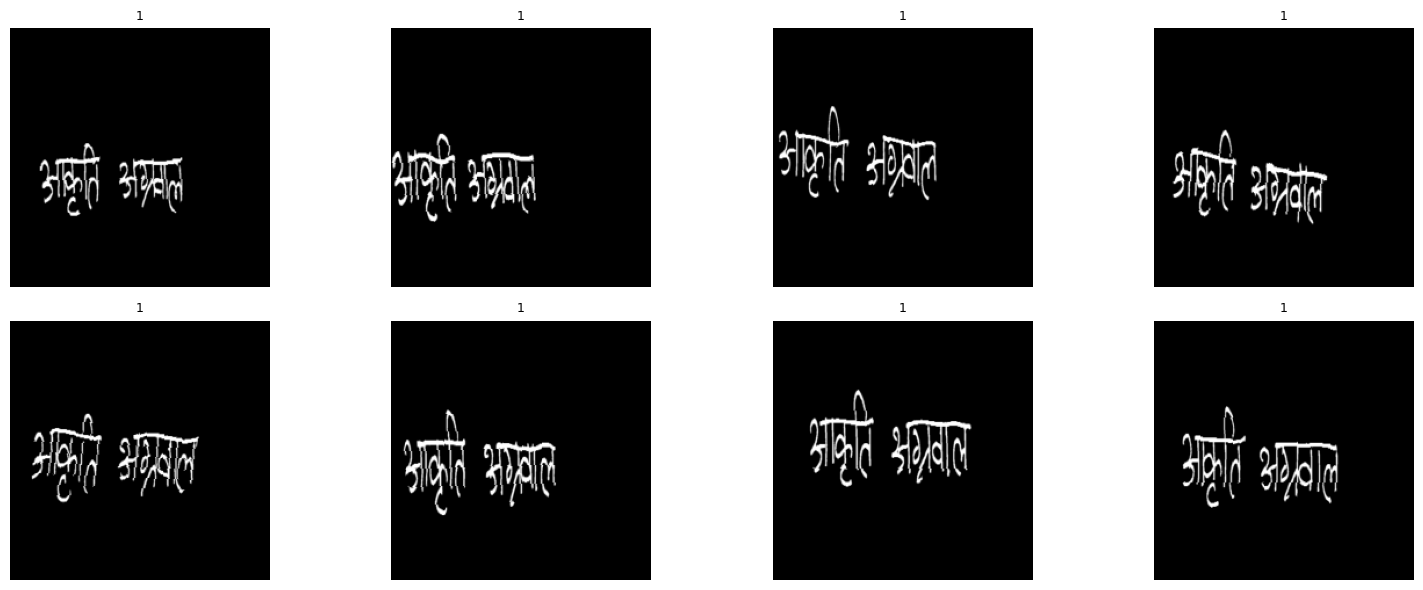

In [6]:
def show_batch(dataset, class_names, num_images=8):
    plt.figure(figsize=(16, 6))
    n = min(num_images, len(dataset))
    for i in range(n):
        img, label = dataset[i]
        arr = img.clone()
        mean = torch.tensor(NORM_MEAN).view(-1, 1, 1)
        std = torch.tensor(NORM_STD).view(-1, 1, 1)
        arr = arr * std + mean
        if arr.shape[0] == 3:
            arr = arr.mean(dim=0)
        else:
            arr = arr.squeeze(0)
        arr = arr.numpy().clip(0, 1)

        plt.subplot(2, 4, i + 1)
        plt.imshow(arr, cmap="gray")
        plt.title(class_names[label], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, class_names, num_images=8)

## Define the model

Custom CNN: 4 conv blocks each doing (Conv3x3 -> GroupNorm -> ReLU -> MaxPool2),
followed by a GAP head. GroupNorm replaces BatchNorm here because BN's running
statistics are unreliable when the training set is tiny (one-batch-per-epoch
degenerate case). GroupNorm normalizes across channel groups within each sample
independently and behaves identically in train and eval mode.

ResNet-18: ImageNet-pretrained weights, `fc` replaced with a fresh
`Linear(512, num_classes)`. Two learning rate groups: low LR for the pretrained
body, normal LR for the new head.

In [7]:
class SignatureCNN(nn.Module):
    """Custom from-scratch CNN. GroupNorm is used instead of BatchNorm to avoid
    train/eval mismatch on tiny datasets."""
    def __init__(self, num_classes):
        super().__init__()

        def block(in_c, out_c):
            # Pick a small group count that divides out_c cleanly. 8 works for
            # 32, 64, 128, 256.
            num_groups = 8
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.GroupNorm(num_groups, out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(1, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x


def build_model(backbone, num_classes):
    if backbone == "custom":
        m = SignatureCNN(num_classes)
        param_groups = [{"params": m.parameters(), "lr": HEAD_LR}]
        return m, param_groups
    elif backbone == "resnet18":
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = m.fc.in_features
        m.fc = nn.Linear(in_features, num_classes)
        head_params = list(m.fc.parameters())
        head_ids = {id(p) for p in head_params}
        backbone_params = [p for p in m.parameters() if id(p) not in head_ids]
        param_groups = [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": HEAD_LR},
        ]
        return m, param_groups
    else:
        raise ValueError(f"Unknown backbone: {backbone}")


model, param_groups = build_model(BACKBONE, num_classes)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone: {BACKBONE}")
print(f"Trainable parameters: {n_params:,}")

Backbone: resnet18
Trainable parameters: 11,258,592


## Loss, optimizer, scheduler

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(param_groups, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

## Training and evaluation functions

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds


def recalibrate_bn(model, loader, device, n_passes=1):
    """Refresh BatchNorm running statistics by doing forward passes in train
    mode with gradients disabled. Only useful for ResNet-18 (custom CNN has
    GroupNorm instead and is unaffected). This is a standard fix for BN
    running-stats drift after fine-tuning on a small dataset."""
    has_bn = any(isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d))
                 for m in model.modules())
    if not has_bn:
        return
    model.train()
    with torch.no_grad():
        for _ in range(n_passes):
            for images, _ in loader:
                images = images.to(device, non_blocking=True)
                model(images)
    model.eval()

## Training loop

In [10]:
train_losses = []
val_losses = []
train_accs_loop = []   # reported during training (train mode)
val_accs = []
lrs = []

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()
    current_lr = optimizer.param_groups[-1]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs_loop.append(train_acc)
    val_accs.append(val_acc)
    lrs.append(current_lr)

    print(f"Epoch {epoch + 1:3d}/{NUM_EPOCHS} | "
          f"lr={current_lr:.2e} | "
          f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val loss={val_loss:.4f} acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed / 60:.2f} minutes")
print(f"Best validation accuracy (during training): {best_val_acc:.4f}")

Epoch   1/50 | lr=3.00e-04 | train loss=4.3767 acc=0.1855 | val loss=2.5154 acc=0.6792
Epoch   2/50 | lr=2.99e-04 | train loss=2.1126 acc=0.7508 | val loss=0.7245 acc=0.9667
Epoch   3/50 | lr=2.97e-04 | train loss=0.7909 acc=0.9633 | val loss=0.1957 acc=0.9917
Epoch   4/50 | lr=2.95e-04 | train loss=0.3364 acc=0.9910 | val loss=0.0836 acc=1.0000
Epoch   5/50 | lr=2.93e-04 | train loss=0.1747 acc=0.9969 | val loss=0.0385 acc=1.0000
Epoch   6/50 | lr=2.89e-04 | train loss=0.1081 acc=0.9969 | val loss=0.0287 acc=0.9979
Epoch   7/50 | lr=2.86e-04 | train loss=0.0779 acc=0.9992 | val loss=0.0161 acc=1.0000
Epoch   8/50 | lr=2.81e-04 | train loss=0.0533 acc=1.0000 | val loss=0.0125 acc=1.0000
Epoch   9/50 | lr=2.77e-04 | train loss=0.0392 acc=0.9996 | val loss=0.0097 acc=1.0000
Epoch  10/50 | lr=2.71e-04 | train loss=0.0286 acc=1.0000 | val loss=0.0076 acc=1.0000
Epoch  11/50 | lr=2.66e-04 | train loss=0.0252 acc=0.9996 | val loss=0.0059 acc=1.0000
Epoch  12/50 | lr=2.59e-04 | train loss=0.0

In [11]:
import os
ckpt_path = os.path.join(RESULTS_DIR, "resnet18_allclasses_best.pt")
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["state_dict"])
best_model_wts = ckpt["state_dict"]
# Dummy values so later cells don't crash on missing variables
train_accs_loop = [0.0]
best_val_acc = 0.0
train_losses = [0.0]
val_losses = [0.0]
val_accs = [0.0]
print("Loaded checkpoint from", ckpt_path)

Loaded checkpoint from ./run_results\resnet18_allclasses_best.pt


C:\Users\katha\AppData\Local\Temp\ipykernel_27664\471548018.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


## Post-training sanity check

We load the best
weights, optionally recalibrate BatchNorm running stats (ResNet-18 only),
then re-evaluate training accuracy in `eval()` mode. If the eval-mode training
accuracy is far below the training-loop train accuracy, something is wrong
with the model's eval behavior.

In [12]:
model.load_state_dict(best_model_wts)

# For ResNet-18 only: refresh BN running statistics on signature data before
# final evaluation. No effect for the custom CNN (it has GroupNorm).
recalibrate_bn(model, train_loader, device, n_passes=2)

# Re-evaluate training accuracy in eval mode.
eval_mode_train_loss, eval_mode_train_acc, train_labels_eval, train_preds_eval = evaluate(
    model, train_eval_loader, criterion, device
)

# Last epoch's training-loop accuracy.
last_loop_train_acc = train_accs_loop[-1] if train_accs_loop else float("nan")

print(f"Train accuracy (training loop, last epoch): {last_loop_train_acc:.4f}")
print(f"Train accuracy (eval mode, best checkpoint): {eval_mode_train_acc:.4f}")

# Raise if the two numbers disagree substantially. A gap of more than 0.15 is
# almost always a sign of BN drift or a train/eval mode inconsistency.
gap = abs(last_loop_train_acc - eval_mode_train_acc)
if gap > 0.15 and last_loop_train_acc > 0.5:
    print(f"\nWARNING: train-loop vs eval-mode accuracy gap = {gap:.3f}")
    print("This usually indicates BN running-stats drift. Investigate before trusting results.")
else:
    print(f"Sanity check passed (gap = {gap:.3f}).")

Train accuracy (training loop, last epoch): 0.0000
Train accuracy (eval mode, best checkpoint): 0.9984
Sanity check passed (gap = 0.998).


## Final test evaluation

In [13]:
test_loss, test_acc, test_labels, test_preds = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix and prediction summary -- most useful for small class counts.
if num_classes <= 10:
    cm = confusion_matrix(test_labels, test_preds, labels=list(range(num_classes)))
    print("\nConfusion matrix (rows=true, cols=predicted):")
    print(cm)
    print(f"\nUnique predictions on test set: {sorted(set(test_preds))}")
    print(f"Unique predictions on val set: {sorted(set(_ for _ in [p for (_, p) in zip(range(len(val_dataset)), [])]))}"
          if False else "")
    # Re-run eval on val just to report the unique-predictions diagnostic.
    _, _, val_labels_diag, val_preds_diag = evaluate(model, val_loader, criterion, device)
    print(f"Unique predictions on val set: {sorted(set(val_preds_diag))}")

Test Loss: 0.0818
Test Accuracy: 0.9962


## Plot training curves

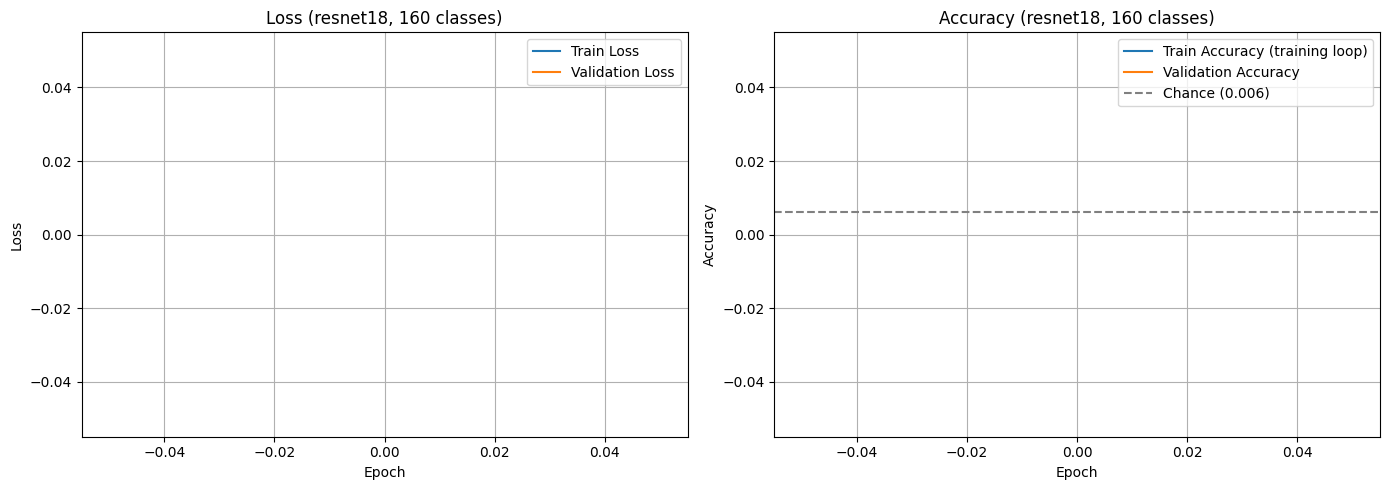

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Loss ({BACKBONE}, {num_classes} classes)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs_loop, label="Train Accuracy (training loop)")
axes[1].plot(val_accs, label="Validation Accuracy")
axes[1].axhline(1.0 / num_classes, color="gray", linestyle="--", label=f"Chance ({1.0/num_classes:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Accuracy ({BACKBONE}, {num_classes} classes)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Qualitative test predictions

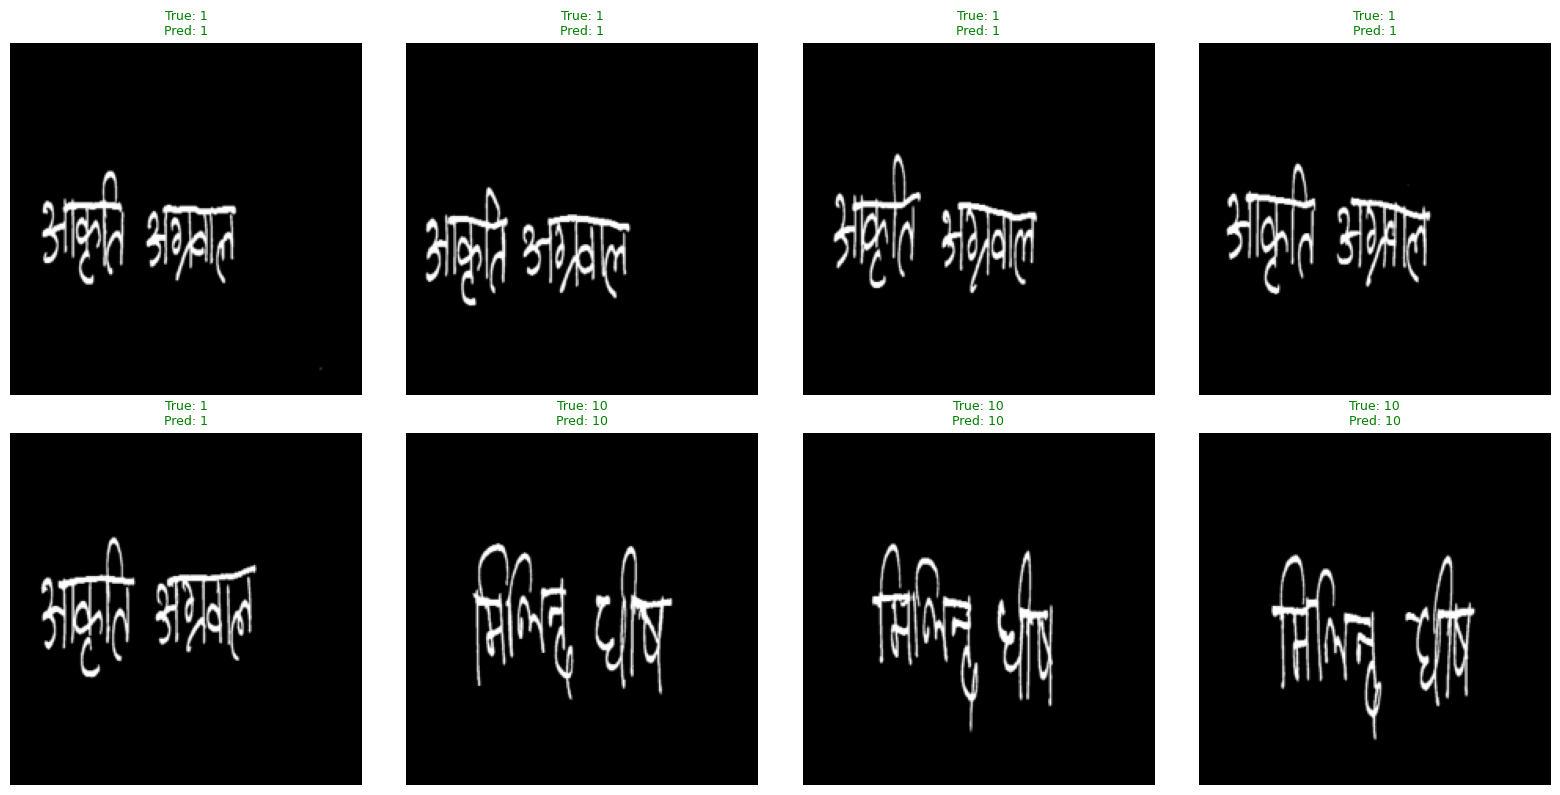

In [15]:
def denormalize_for_display(img_tensor):
    mean = torch.tensor(NORM_MEAN).view(-1, 1, 1)
    std = torch.tensor(NORM_STD).view(-1, 1, 1)
    arr = img_tensor * std + mean
    if arr.shape[0] == 3:
        arr = arr.mean(dim=0)
    else:
        arr = arr.squeeze(0)
    return arr.clip(0, 1).numpy()


images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_device)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(16, 8))
for i in range(min(8, len(images))):
    img = denormalize_for_display(images[i])
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if labels[i] == preds[i] else "red"

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9, color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Summary + persist result to disk

In [16]:
chance_baseline = 1.0 / num_classes
lift = test_acc / chance_baseline

result = {
    "run_tag": RUN_TAG,
    "backbone": BACKBONE,
    "num_classes": num_classes,
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_val_acc": float(best_val_acc),
    "eval_mode_train_acc": float(eval_mode_train_acc),
    "test_acc": float(test_acc),
    "test_loss": float(test_loss),
    "chance_acc": float(chance_baseline),
    "lift_over_chance": float(lift),
    "train_loss_history": [float(x) for x in train_losses],
    "val_loss_history": [float(x) for x in val_losses],
    "train_acc_history": [float(x) for x in train_accs_loop],
    "val_acc_history": [float(x) for x in val_accs],
}

with open(RESULT_PATH, "w") as f:
    json.dump(result, f, indent=2)

print("========== SUMMARY ==========")
print(f"Run tag                : {RUN_TAG}")
print(f"Backbone               : {BACKBONE}")
print(f"Number of classes      : {num_classes}")
print(f"Training samples       : {len(train_dataset)}")
print(f"Validation samples     : {len(val_dataset)}")
print(f"Test samples           : {len(test_dataset)}")
print(f"Epochs                 : {NUM_EPOCHS}")
print(f"Best validation acc    : {best_val_acc:.4f}")
print(f"Train acc (eval mode)  : {eval_mode_train_acc:.4f}")
print(f"Final test accuracy    : {test_acc:.4f}")
print(f"Final test loss        : {test_loss:.4f}")
print(f"Chance accuracy        : {chance_baseline:.4f}  (1 / {num_classes})")
print(f"Lift over chance       : {lift:.1f}x")
print(f"Saved result to        : {RESULT_PATH}")
print("=============================")

========== SUMMARY ==========
Run tag                : resnet18_allclasses
Backbone               : resnet18
Number of classes      : 160
Training samples       : 2560
Validation samples     : 480
Test samples           : 800
Epochs                 : 50
Best validation acc    : 0.0000
Train acc (eval mode)  : 0.9984
Final test accuracy    : 0.9962
Final test loss        : 0.0818
Chance accuracy        : 0.0063  (1 / 160)
Lift over chance       : 159.4x
Saved result to        : ./run_results\resnet18_allclasses.json


## Aggregate all completed runs into a results table

Run this cell after you have completed all 6 sweep configurations. It scans
the `./run_results/` directory and assembles everything into a single
comparison table.

In [ ]:
# Gemini helped with this idea and build it.
import glob

result_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.json")))
if not result_files:
    print("No result files found in", RESULTS_DIR)
else:
    print(f"Found {len(result_files)} completed run(s):\n")
    header = f"{'backbone':10s} {'classes':>8s} {'test_acc':>10s} {'val_acc':>10s} {'train_acc':>10s} {'chance':>8s} {'lift':>8s}"
    print(header)
    print("-" * len(header))

    rows = []
    for path in result_files:
        with open(path) as f:
            r = json.load(f)
        rows.append(r)

    # Sort by backbone, then class count
    rows.sort(key=lambda r: (r["backbone"], r["num_classes"]))
    for r in rows:
        print(f"{r['backbone']:10s} {r['num_classes']:>8d} "
              f"{r['test_acc']:>10.4f} {r['best_val_acc']:>10.4f} "
              f"{r['eval_mode_train_acc']:>10.4f} "
              f"{r['chance_acc']:>8.4f} {r['lift_over_chance']:>7.1f}x")

Found 6 completed run(s):

backbone    classes   test_acc    val_acc  train_acc   chance     lift
----------------------------------------------------------------------
custom            2     1.0000     1.0000     0.9688   0.5000     2.0x
custom           10     0.7600     0.7667     0.8000   0.1000     7.6x
custom          160     0.4875     0.4958     0.5395   0.0063    78.0x
resnet18          2     1.0000     1.0000     1.0000   0.5000     2.0x
resnet18         10     1.0000     1.0000     1.0000   0.1000    10.0x
resnet18        160     0.9962     0.0000     0.9984   0.0063   159.4x
